# Informatics 1 Cognitive Science 2025/26

# Assignment 1

<div class="alert alert-success">

### How to use this notebook

<b>File name:</b> You **must not change the name of the assignment file**. Doing so is likely to lead to your assignment not being marked properly.
<br>
<b>Read-only cells:</b> You may notice that there are some cells which you cannot edit (usually cells which explain the question) - these cells are read only.
<br>
<b>Your answer:</b> Cells which are left blank for your responses will either require a text response or a code response. This will be clear from the question, but you should check that a text response is written in a markdown cell, and a code response is written in a code cell (as indicated in the toolbar).
<b>Code answers:</b> In questions that require you to write code, there will usually be a code cell containing: 
    
<code># YOUR CODE HERE</code>
<br>
<code>raise NotImplementedError()</code>
    
When you are ready to write your answer, **delete or comment out** <code>raise NotImplementedError()</code> and write your code.

<b>Text answers:</b> For questions with a text answer, there will be a markdown cell following the question. There will usually be an indication that the cell is intended for your answer such as <code>"YOUR ANSWER HERE"</code>, which you can replace with your response.
    
<b>Assert statements:</b> You may notice that some lines of code starting with <code>assert</code> cause errors when run multiple times. If your answer is correct, these tests should pass when you restart your notebook and run all cells in order.
    
### Submitting your work

Before you submit, ensure that the notebook can be run from start to finish by pressing the "Restart & Run All" option in the "Kernel" menu above.
    
You should <b>run your notebook and save your work</b> before you submit. 
    
Once you are ready, go to the assignments tab on the Noteable landing page and click "Submit" on the relevant assignment.
    
**You are allowed to submit multiple times**. Please be aware that we will mark your last submission even if this is after the deadline. Therefore to avoid late penalties, you should not submit after the deadline. It may take a few minutes to submit your assignment so please bear this in mind when timing your submission. If you have not previously submitted an assignment through Noteable, we recommend you submit an early version of your assignment so that you can ensure you understand this process. You can also walk through this process with a lab demonstrator if you are unsure.

<b>Note:</b> The Noteable system is undergoing continuous updates. As such, there may be changes which we have not yet seen. If you have issues with using the assignment, please let the course teaching assistant (Jordan Watts, [J.Watts-2@sms.ed.ac.uk](mailto:J.Watts-2@sms.ed.ac.uk)) know so that we can provide support.

<b>If you have any issues submitting:</b> Download your notebook by right-clicking on the file name in the file tree on the left and selecting "Download". You can then email this file to the course organiser (Matthias Hennig, [m.hennig@ed.ac.uk](mailto:m.hennig@ed.ac.uk)) as evidence of a timely submission. You may still need to submit via Noteable so please pay close attention to any updated instructions from course staff.

</div>

In [130]:
# this is to plot inside the notebook
%matplotlib inline

# these are the libraries we are going to use
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import misc

# we are also going to use helper functions from the RM1985.py file
from RM1985 import *

matplotlib.style.use('seaborn-v0_8-notebook')

import warnings
warnings.filterwarnings('ignore')

np.random.seed(2222)

# PART 1

In this part of the assignment, we're going to replicate Rumelhart and McClelland's (1985) model of the past tense (pictured below).
If you're itching to read the source paper, it's included in the Assignment 1 directory and may be a handy reference. We're going to walk through the necessary components here.

Most of the functions we need for the RM model are already implemented for us: Have a look at the file `RM1985.py` if you want to know the details.

![](images/modelStructure.png)


## Encoding the input

The model uses a phonological representation called wickelfeatures. 

Words (e.g., came) are translated into phonemes (e.g., kAm).

Phonemes are converted into a binary code based on their articulatory features (see below).
In RM's model we use wickelphones (triplets of phonemes; e.g., #kA, kAm, Am#).

In [131]:
word_to_wickelphone('kAm')

[['0000000000', '1001000101', '0010110010'],
 ['1001000101', '0010110010', '1000110010'],
 ['0010110010', '1000110010', '0000000000']]

In practice, we also add a bit representing if a wickelphone touches a word boundary, resulting in an 11 bit code for each phoneme. You will not need the specifics of the code for this assignment.

Wickelphones are converted into wickelfeatures by taking one of the bits from the first phoneme in a wickelphone, one of the bits from the second phoneme, and one of the bits from the third. In theory then, there are 11 * 11 * 11 possible wickelfeatures. However, in practice a lot of these combinations are redundant and we can represent all informative combinations with just 460 wickelfeatures. If you're really itching for the details they're in the paper.

Luckily, we have a helper function that will do all of this encoding for us: `activate_word`

In [132]:
activate_word('kAm')

[0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,


We should check some properties of our encoding function. 

In order to do this we first have to translate some words (e.g., came) into phonemes (e.g. kAm). 

A lot of letters in English map directly onto their phoneme (e.g., b -> b) however, there are a few that don't (e.g., c as in *car* is represented by a k). The table below should help you translate words into phonemes (particularly the caption helps with vowels):

![](images/IPA.png)

<div class="alert alert-info" role="alert">
<h1>Exercise 1a)</h1>
<p>
Let's translate the ten high frequency words used in the paper: 

come/came, look/looked, feel/felt, have/had, make/made, get/got, give/gave, take/took, go/went, like/liked

(Points 2)
</p>
</div>



In [133]:
# save the phoneme representations of the base verb and past tense verb here
# keep the order in the quetion above: come, look, feel, have, make, get, give, take, go, like
# high_frequency_verbs = ['come', 'look', 'feel', 'have', 'make', 'get', 'give', 'take', 'go', 'like']
# base_high_frequency_verbs = ['k*m', 'luk', ...]
# past_high_frequency_verbs = ['kAm', 'lukt', ...]

high_frequency_verbs = ['come', 'look', 'feel', 'have', 'make', 'get', 'give', 'take', 'go', 'like']

# YOUR CODE HERE
base_high_frequency_verbs  = ['k*m', 'luk', 'fEl', 'hav', 'mAk', 'get', 'giv', 'tAk', 'gO', 'lIk']
past_high_frequency_verbs  = ['kAm', 'lukt', 'felt', 'had', 'mAd', 'got', 'gAv', 'tuk', 'went', 'lIkt']

In [134]:
"""Check that translation was correct"""
for i, w in enumerate(high_frequency_verbs):
    print(w, 'Base:', activate_word(base_high_frequency_verbs[i]) == base_HF_activations[i])
    print(w, 'Past:', activate_word(past_high_frequency_verbs[i]) == past_HF_activations[i])

print(activate_word(past_high_frequency_verbs[9]))

come Base: True
come Past: True
look Base: True
look Past: True
feel Base: True
feel Past: True
have Base: True
have Past: True
make Base: True
make Past: True
get Base: True
get Past: True
give Base: True
give Past: True
take Base: True
take Past: True
go Base: True
go Past: True
like Base: True
like Past: True
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0

Now let's check some properties of our encoding function: `activate_word`

As mentioned above, there should be 460 wickelfeatures for each word. We can check this using `np.shape`

For a three phoneme word like *came*, we expect there to be at most 16 active wickelfeatures.

<div class="alert alert-info" role="alert">
<h1>Exercise 1b)</h1>
<p>
    
Store the shape of the wickelfeature represetation for *came* and the number of wickelfeatures activated (i.e., set to 1).
    
(Points 2)
    
</p>
</div>


In [135]:
# compute the shape and the number of active wickelfeatures here
# came_activation = np.array(activate_word('kAm'))
# came_shape = ...
# came_number_active_wickelfeatures = ...

came_activation = np.array(activate_word('kAm'))

# YOUR CODE HERE
came_shape = came_activation.shape
came_number_active_wickelfeatures = np.sum(came_activation)


In [136]:
"""Check the shape and number of active wickelfeatures is correct"""
assert(came_shape == (460,))
assert(came_number_active_wickelfeatures == 16)

 ## The Model
 
 Now that we have our input representations, we can work on the model implementation.
 
The goal of RM's model is to output a wickelfeature representation for the past tense of the input verb. To do this, they build a perceptron for each of the 460 possible wickelfeatures. Each perceptron receieves the entire phonological representation of the base verb as input and decides if a single wickelfeature should be present in the output.

We have implemented the standard percepton model for you in the file `RM1985.py`; however, there is one difference between a standard perceptron and the ones used by RM.

In the standard perceptron, a unit fires if the weighted activation `net` is greater than a threshold `theta`; otherwise it does not fire.

In RM's perceptron, a unit fires probabilistically according to the activation function:

$$ p(net, \theta, T) =  \frac{1}{1 + e^{-(net-\theta)/T}} $$


<div class="alert alert-info" role="alert">
<h1>Exercise 2a)</h1>
<p>
Translate this function into code.

(Points 2)
</p>
</div>

Hint: the exponential function can be calculated using `np.exp()`


In [137]:
# translate the function here
#
# def rm_activation_function(net, theta, T=1.0):
#     # YOUR CODE HERE
#     # probability = ...
#     return probability

# YOUR CODE HERE
def rm_activation_function(net, theta, T=1.0):
    probability = 1 / (1 + np.exp(-(net - theta) / T))
    return probability

In [138]:
"""Check the functions output"""
assert(rm_activation_function(0, 0.0) == 0.5)
assert(rm_activation_function(1., 0., 1.0) == 0.7310585786300049)
assert(rm_activation_function(2., 1., T=2.) == 0.6224593312018546)



RM's activation function looks quite similar to the sigmoid function we discussed in lecture 6. However, what does the `T` parameter do?

Let's vizualize it.

<div class="alert alert-info" role="alert">
<h1>Exercise 2b)</h1>
<p>
    
Let's set `theta = 0.0` and plot the probability of firing as a function of the the weighted activation `net` at `T=1.0`, `T=0.5` and `T=2.0` in one figure. We should consider weighted activation values between -5 and 5.

(Points 4)
    
</p>
</div>

For full credit you should:

- Plot the probability of firing (Y-axis) as a function of weighted activation, net, (X-axis) on the same plot (choose distinguishable colors please).
- Set labels for both axes.
- Set a title for the figure.
- Set the plot to span (0, 1) for the y-axis and and (-5, 5) for the x-axis
- Set a legend indicating how colors map to values of T

Please have a look at lab 3 if you need a reminder on how to do plotting in Python!


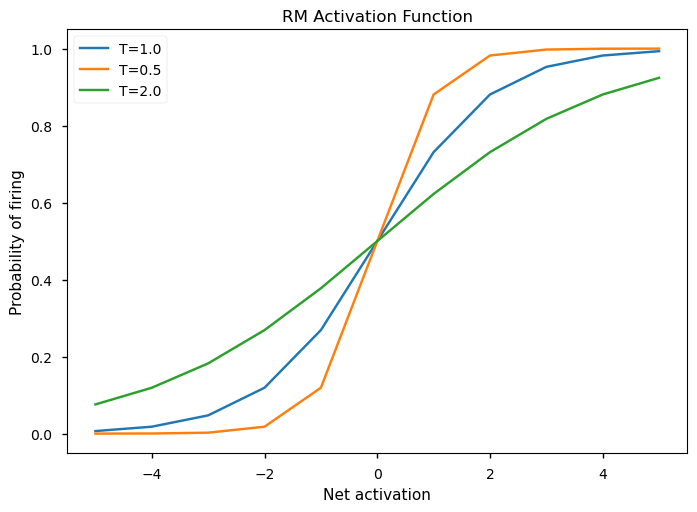

In [139]:
# calculate and plot the probability of firing at different T values
# 
# net_activation = np.arange(-5, 6)
# p_T1 = rm_activation_function(net_activation, theta=0.0, T=1.0)
# p_T05 = ...
# p_T2 = ...
#

# YOUR CODE HERE
net_activation = np.arange(-5, 6)
p_T1 = rm_activation_function(net_activation, theta=0.0, T=1.0)
p_T05 = rm_activation_function(net_activation, theta=0.0, T=0.5)
p_T2 = rm_activation_function(net_activation, theta=0.0, T=2.0)

plt.plot(net_activation, p_T1, label='T=1.0')
plt.plot(net_activation, p_T05, label='T=0.5')
plt.plot(net_activation, p_T2, label='T=2.0')
plt.xlabel('Net activation')
plt.ylabel('Probability of firing')
plt.title('RM Activation Function')
plt.legend()
plt.show()  

<div class="alert alert-info" role="alert">
<h1>Exercise 2c)</h1>
<p>
Discuss how this activation function differs from the standard perceptron activation function. (max 5 sentences)

(Points 2)
</p>
</div>



The standard perceptron activation function is a binary step function that maps the weighted sum of inputs to a deterministic 0 or 1 output based on a fixed threshold, whereas RM's activation function is a logistic/sigmoid function that returns the probability of a unit firing. Unlike the step function, which has a gradient of zero everywhere except at the discontinuity, the sigmoid is smooth and differentiable across its entire range. A key distinction of RM's implementation is the temperature parameter T, which controls the steepness of the curve — at low T the function approximates a binary step function, while at high T outputs become nearly uniform, effectively slowing learning. Additionally, the threshold θ is a learnable parameter adjusted during training alongside the weights, unlike the fixed threshold of a standard perceptron. Finally, because the output is probabilistic rather than deterministic, the same input can yield different outputs across trials, introducing stochasticity that is critical for the gradual interference between regular and irregular verbs that drives the three-stage learning phenomenon.

# U Shaped Curves

RM used this model to demonstrate a developmental U-shape curve.

First they trained the model on ten high frequency words (8 irregular, 2 regular), then medium frequency verbs, then low frequency verbs. They then plotted the percent of wickelfeatures the model correctly predicted for irregular and regular verbs as the model saw more data. 

Let's replicate this step by step :)

First, let's load in a corpus of English verbs.

In [140]:
# read in the corpus

verbs = []
with open('verbs.csv') as f:
    for i, line in enumerate(f.readlines()):
        if i == 0:
            print(line.strip('\n').split(','))
        else:
            verbs.append(line.strip('\n').split(','))
            print(verbs[-1])

# add in the high frequency verbs you translated for us earlier
for i, word in enumerate(high_frequency_verbs):
    if word in ['look', 'like']:
        verbs.append([word, 'Regular', base_high_frequency_verbs[i], past_high_frequency_verbs[i], 'H'])
    else:
        verbs.append([word, 'Irregular', base_high_frequency_verbs[i], past_high_frequency_verbs[i], 'H'])
    print(verbs[-1])


['Verb', 'Type', 'Base', 'Past', 'Frequency']
['act', 'Regular', 'akt', 'akted', 'M']
['age', 'Regular', 'Aj', 'Ajd', 'M']
['air', 'Regular', 'Ar', 'Ard', 'M']
['arise', 'Irregular', '*rIz', '*rOz', 'M']
['ask', 'Regular', 'ask', 'askt', 'M']
['back', 'Regular', 'bak', 'bakt', 'M']
['bear', 'Irregular', 'bAr', 'bor', 'M']
['beat', 'Irregular', 'bEt', 'bEt', 'M']
['become', 'Irregular', 'bEk*m', 'bEkAm', 'M']
['believe', 'Regular', 'b*lEv', 'b*lEvd', 'M']
['bend', 'Irregular', 'bend', 'bent', 'L']
['bid', 'Irregular', 'bid', 'bid', 'L']
['bleed', 'Irregular', 'blEd', 'bled', 'M']
['blow', 'Irregular', 'blO', 'blU', 'M']
['board', 'Regular', 'bord', 'borded', 'M']
['brake', 'Irregular', 'brAk', 'brOk', 'M']
['breed', 'Irregular', 'brEd', 'bred', 'L']
['bring', 'Irregular', 'briN', 'brot', 'M']
['brown', 'Regular', 'brWn', 'brWnd', 'L']
['build', 'Irregular', 'bild', 'bilt', 'M']
['buy', 'Irregular', 'bI', 'bot', 'M']
['call', 'Regular', 'kol', 'kold', 'M']
['carp', 'Regular', 'karp', 'ka

- The first column denotes the verb.
- The second column denotes whether the verb is regular or irregular.
- The third column denotes the phoneme representation of the base verb.
- The fourth column denotes the phoneme representation of the past tense verb.
- The last column denotes the verb's frequency (M: Medium or L: Low)

## First Stage: High Frequency Verbs

In the first stage, RM trained the model on the high frequency verbs.

Let's do that.

First we need to convert the phonemes into wickelfeatures.

In [141]:
base_wickel_HF = np.array([activate_word(w) for w in base_high_frequency_verbs]).T
past_wickel_HF = np.array([activate_word(w) for w in past_high_frequency_verbs]).T

Next we initialize a perceptron with our custom activation function

In [142]:
percept = Perceptron(active=rm_activation_function)

Now let's do the perceptron learning algorithm for each high frequency word (i.e. one epoch).

The function `Perceptron.learn()` does one epoch of weight updates and then returns the model accuracy on the data. This is the percentage of the wickelfeatures the model correctly predicts.

In [143]:
percept.learn(base_wickel_HF, past_wickel_HF)

array([0.96956522, 0.94347826, 0.93913043, 0.97608696, 0.95869565,
       0.97173913, 0.95      , 0.96304348, 0.84347826, 0.93695652])

We can also score the perceptron, using `Perceptron.score()`. This just returns the accuracy, without updating the weights.

In [144]:
percept.score(base_wickel_HF, past_wickel_HF)

array([0.97173913, 0.94347826, 0.94347826, 0.9673913 , 0.96304348,
       0.97608696, 0.9673913 , 0.96304348, 0.86956522, 0.93043478])

So after one epoch, the perceptron performs well on the verbs it has seen already. 

How will the perceptron perform on all the irregular and regular verbs, including the ones it has not seen yet?

<div class="alert alert-info" role="alert">
<h1>Exercise 3a)</h1>
<p>
    
Now let's divide the corpus `verbs` into two lists: one for regular verbs and one for irregular verbs.

(Points 2)
    
</p>
</div>

Hint: You may want to use a `for` loop over `verbs`


In [145]:
# store the two sets here
#
# regular_verbs = ...
# irregular_verbs = ...

# YOUR CODE HERE
regular_verbs = [v for v in verbs if v[1] == 'Regular']
irregular_verbs = [v for v in verbs if v[1] == 'Irregular']

In [146]:
assert(len(regular_verbs) == 96)
assert(len(irregular_verbs) == 96)

Now let's score the perceptron's performance on both the regular and irregular verbs.

<div class="alert alert-info" role="alert">
<h1>Exercise 3b)</h1>
<p>
First convert the phonemes for base and past tense into wickelfeatures. Then calculate the mean score of the model on irregular and regular verbs.
    
(Points 3)</p>
</div>

Hint: Look back to how we coverted phonemes into wickelfeatures above.


In [147]:
# convert irregular and regular verbs into wickelfeatures
#
# base_wickel_irregular = ...
# past_wickel_irregular = ...
# base_wickel_regular = ...
# past_wickel_regular = ...
#
# irregular_score = np.mean(percept.score(base_wickel_irregular, past_wickel_irregular))
# regular_score = np.mean(percept.score(base_wickel_irregular, past_wickel_irregular))

# YOUR CODE HERE
base_wickel_irregular = np.array([activate_word(v[2]) for v in irregular_verbs]).T
past_wickel_irregular = np.array([activate_word(v[3]) for v in irregular_verbs]).T
base_wickel_regular = np.array([activate_word(v[2]) for v in regular_verbs]).T
past_wickel_regular = np.array([activate_word(v[3]) for v in regular_verbs]).T

irregular_score = np.mean(percept.score(base_wickel_irregular, past_wickel_irregular))
regular_score = np.mean(percept.score(base_wickel_regular, past_wickel_regular))

In [148]:
assert irregular_score == 0.9153306159420289
assert regular_score == 0.8764719202898551

So far we've trained the model in batch, which means it has seen all the data once before we score it.

Let's train the model one data point at a time and score it after each datapoint

In [149]:
# Let's initialize a new perceptron with our custom activation function
percept = Perceptron(active=rm_activation_function)


# Now let's loop through each data point to train and score
scores_regular = []
scores_irregular = []
for i in range(len(high_frequency_verbs)):
    percept.learn(base_wickel_HF[:,i, np.newaxis], past_wickel_HF[:,i,np.newaxis])
    scores_regular.append(np.mean(percept.score(base_wickel_regular, past_wickel_regular)))
    scores_irregular.append(np.mean(percept.score(base_wickel_irregular, past_wickel_irregular)))
    print(scores_regular[-1], scores_irregular[-1])


0.6128396739130434 0.6086050724637682
0.6736413043478261 0.6753396739130434
0.7201766304347826 0.7194972826086957
0.7450860507246376 0.7426177536231884
0.7699728260869566 0.7745471014492754
0.7841485507246378 0.7931385869565216
0.7972146739130433 0.8102355072463768
0.8058197463768115 0.8263813405797102
0.8115489130434783 0.8335371376811594
0.821490036231884 0.8413722826086957


<div class="alert alert-info" role="alert">
<h1>Exercise 3c)</h1>
<p>
Explain the model output. So far, do we replicate RM? Do we expect to get the same result if we rerun the model? (7 sentences max)
    
(Points 3)</p>
</div>

Both regular and irregular scores start low (~61%) and rise steadily together until ~82% and ~84% respectively, after training on all 10 high-frequency verbs, with only a ~2% difference between them, indicating the model shows no meaningful advantage for either verb type at this stage. This is consistent with RM's Stage 1, where children simply know a small number of separate items as rote associations rather than extracting any general rule. We partially replicate RM in that performance improves with each training example. However we differ in that RM trains for 10 full cycles over the high-frequency verbs, whereas here we only do a single sequential pass, meaning our model has seen less training data at this point. The U-shaped curve has not yet emerged since we have not introduced the medium-frequency verbs that cause the characteristic dip in irregular performance. We would not expect identical results if we reran the model without a fixed random seed, since the probabilistic activation function introduces stochasticity into the weight updates. However, the seed is fixed to 2222 at the top of the notebook, so rerunning will always reproduce these exact values.

## Second Stage: Medium Frequency Verbs

In the second stage of the U-Shape curve, RM train the model with medium frequency verbs. Let's do it!

<div class="alert alert-info" role="alert">
<h1>Exercise 4a)</h1>
<p>
    
First, we need to extract the medium frequency verbs from the corpus `verbs`.
    
(Points 1)
    
</p>
</div>


In [150]:
# store the medium frequency verbs here
#
# base_med_frequency_verbs = ...
# past_med_frequency_verbs = ...

# YOUR CODE HERE
base_med_frequency_verbs = [v[2] for v in verbs if v[4] == 'M']
past_med_frequency_verbs = [v[3] for v in verbs if v[4] == 'M']

In [151]:
assert(len(base_med_frequency_verbs) == 150)
assert(len(past_med_frequency_verbs) == 150)

<div class="alert alert-info" role="alert">
<h1>Exercise 4b)</h1>
<p>
Second, we need to convert those those verbs into wickelfeatures.
    
(Points 2)</p>
</div>


In [152]:
# convert the verbs into wickelfeatures
#
# base_wickel_MF = ...
# past_wickel_MF = ...

# YOUR CODE HERE
base_wickel_MF = np.array([activate_word(w) for w in base_med_frequency_verbs]).T
past_wickel_MF = np.array([activate_word(w) for w in past_med_frequency_verbs]).T

Now, we need to loop through each data point to train and score, like we just did for the high frequency verbs.

<div class="alert alert-info" role="alert">
<h1>Exercise 4c)</h1>
<p>
    
Calculate and store the scores for regular and irregular verbs in the variables `scores_irregular_md` and `scores_regular_md`.
    
(Points 2)
    
</p>
</div>


In [153]:
# loop through the medium frequency verbs to train and score the model here
#
# scores_regular_md = []
# scores_irregular_md = []
# for i in range(len(base_med_frequency_verbs)):
#    # YOUR CODE HERE
#    print(scores_regular_md[-1], scores_irregular_md[-1])

# YOUR CODE HERE
scores_regular_md = []
scores_irregular_md = []
for i in range(len(base_med_frequency_verbs)):
    percept.learn(base_wickel_MF[:,i, np.newaxis], past_wickel_MF[:,i,np.newaxis])
    scores_regular_md.append(np.mean(percept.score(base_wickel_regular, past_wickel_regular)))
    scores_irregular_md.append(np.mean(percept.score(base_wickel_irregular, past_wickel_irregular)))
    print(scores_regular_md[-1], scores_irregular_md[-1])

0.8294384057971015 0.844134963768116
0.8349411231884059 0.8518568840579711
0.8407382246376812 0.8586503623188406
0.8392436594202898 0.8608016304347826
0.8417119565217392 0.8653079710144927
0.844338768115942 0.8620018115942029
0.8530344202898551 0.8726222826086957
0.8544157608695652 0.8752717391304348
0.8444293478260869 0.8601675724637681
0.8371829710144928 0.8459012681159419
0.8456748188405797 0.8658514492753623
0.8519927536231885 0.877151268115942
0.8587409420289855 0.8656929347826088
0.8601222826086956 0.868953804347826
0.8598505434782608 0.8765851449275361
0.86268115942029 0.8872509057971015
0.8645833333333334 0.886435688405797
0.8687952898550725 0.8927536231884058
0.8584239130434782 0.8721920289855073
0.8664402173913043 0.8843523550724638
0.8707427536231883 0.8891983695652174
0.8666213768115941 0.8828125
0.8701086956521739 0.8830163043478261
0.875769927536232 0.8857336956521739
0.8746829710144928 0.8858016304347825
0.8673686594202898 0.8729846014492754
0.8788722826086955 0.88213315

In [154]:
assert scores_regular_md[-1] == 0.931816123188406
assert scores_irregular_md[-1] == 0.9442028985507246

## Third Stage: Low Frequency Verbs

In the third stage of the U-Shape curve, RM train the model with low frequency verbs. One last time then :)

<div class="alert alert-info" role="alert">
<h1>Exercise 4d)</h1>
<p>
    
First, we need to extract the low frequency verbs from the corpus `verbs`.
    
(Points 1)
    
</p>
</div>

In [155]:
# store the low frequency verbs here
#
# base_low_frequency_verbs = ...
# past_low_frequency_verbs = ...

# YOUR CODE HERE
base_low_frequency_verbs = [v[2] for v in verbs if v[4] == 'L']
past_low_frequency_verbs = [v[3] for v in verbs if v[4] == 'L']

In [156]:
assert(len(base_low_frequency_verbs) == 32)
assert(len(past_low_frequency_verbs) == 32)

<div class="alert alert-info" role="alert">
<h1>Exercise 4e)</h1>
<p>
Second, we need to convert those those verbs into wickelfeatures.
    
(Points 2)</p>
</div>


In [157]:
# convert the verbs into wickelfeatures
#
# base_wickel_LF = ...
# past_wickel_LF = ...

# YOUR CODE HERE
base_wickel_LF = np.array([activate_word(w) for w in base_low_frequency_verbs]).T
past_wickel_LF = np.array([activate_word(w) for w in past_low_frequency_verbs]).T

Finally, we need to loop through each data point to train and score.

<div class="alert alert-info" role="alert">
<h1>Exercise 4f)</h1>
<p>
    
Calculate and store the scores for regular and irregular verbs in the variables `scores_irregular_low` and `scores_regular_low`.
    
(Points 2)
</p>
</div>


In [158]:
# loop through the medium frequency verbs to train and score the model here
#
# scores_regular_low = []
# scores_irregular_low = []
# for i in range(len(base_low_frequency_verbs)):
#    # YOUR CODE HERE
#    print(scores_regular_low[-1], scores_irregular_low[-1])

# YOUR CODE HERE
scores_regular_low = []
scores_irregular_low = []
for i in range(len(base_low_frequency_verbs)):
    percept.learn(base_wickel_LF[:,i, np.newaxis], past_wickel_LF[:,i,np.newaxis])
    scores_regular_low.append(np.mean(percept.score(base_wickel_regular, past_wickel_regular)))
    scores_irregular_low.append(np.mean(percept.score(base_wickel_irregular, past_wickel_irregular)))
    print(scores_regular_low[-1], scores_irregular_low[-1])

0.931453804347826 0.9478034420289855
0.9314311594202898 0.949207427536232
0.9332653985507248 0.9483695652173912
0.9314085144927535 0.9481657608695652
0.9361865942028986 0.9485733695652173
0.935733695652174 0.9493432971014492
0.9356657608695652 0.9484827898550724
0.9345788043478261 0.9488903985507248
0.9347146739130435 0.949230072463768
0.9355072463768117 0.9487545289855072
0.931838768115942 0.9505434782608694
0.9377264492753624 0.9495244565217392
0.938473731884058 0.9498867753623189
0.9386548913043479 0.948052536231884
0.9383605072463768 0.9487318840579709
0.9394701086956522 0.9490262681159419
0.9407382246376811 0.9500905797101451
0.9403759057971014 0.9479846014492753
0.9412590579710146 0.9458559782608695
0.944429347826087 0.9448369565217392
0.9436141304347827 0.9454936594202898
0.943546195652174 0.9457880434782608
0.9449048913043477 0.9457201086956522
0.944542572463768 0.9436820652173914
0.9434782608695652 0.9446331521739131
0.9440670289855072 0.9467617753623189
0.9427762681159421 0.9

In [159]:
assert(scores_regular_low[0] == 0.931453804347826)
assert(scores_irregular_low[0] == 0.9478034420289855)
assert scores_regular_low[-1] == 0.9438858695652174
assert scores_irregular_low[-1] == 0.9526947463768116

## Putting it all together

<div class="alert alert-info" role="alert">
<h1>Exercise 5a)</h1>
<p>
Let's see how well we replicated the U-Shape pattern by plotting the simulation output.
    
(Points 4)</p>
</div>

For full credit your code should:

- Plot the percent of correct wickelfeatures (Y-axis) as a function of the amount of datapoints trained on for both regular and irregular verbs (use distinct colors please).
- Plot dashed vertical lines at 10 and 160 data points to demarcate the three different time periods.
- Set labels for both axes.
- Set a title for the figure.
- Set the plot to span (0.5, 1) for the y-axis and and (0, 192) for the x-axis
- Set a legend indicating how colors map to verb type

Hint: to concatenate two lists into a bigger list you can use the following syntax:
`big_list = one_list + another_list`


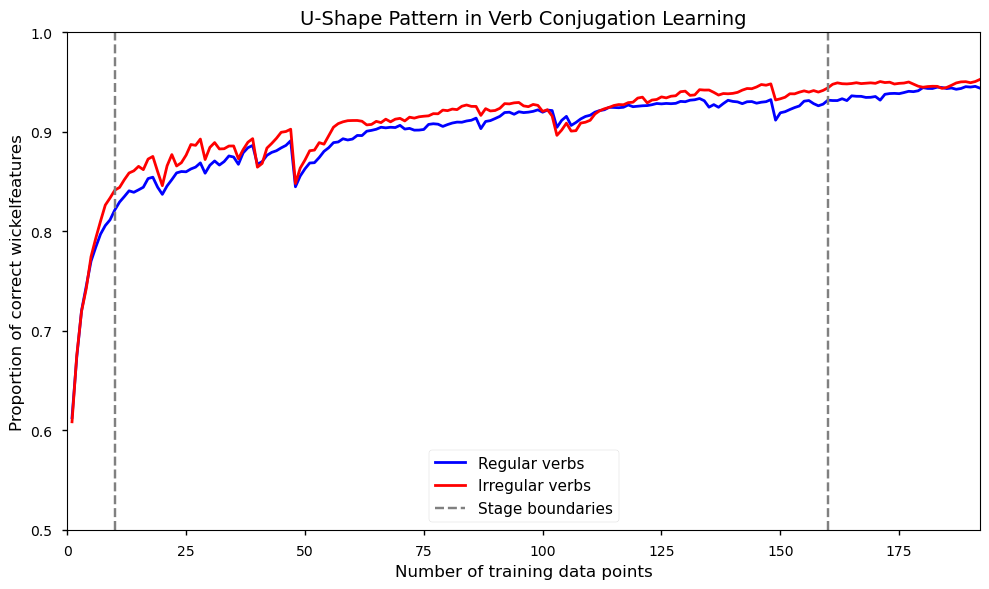

In [166]:
all_scores_regular = scores_regular + scores_regular_md + scores_regular_low
all_scores_irregular = scores_irregular + scores_irregular_md + scores_irregular_low

x_values = list(range(1, len(all_scores_regular) + 1))

plt.figure(figsize=(10, 6))
plt.plot(x_values, all_scores_regular, color='blue', label='Regular verbs', linewidth=2)
plt.plot(x_values, all_scores_irregular, color='red', label='Irregular verbs', linewidth=2)
plt.axvline(x=10, color='gray', linestyle='--', label='Stage boundaries')
plt.axvline(x=160, color='gray', linestyle='--')
plt.xlim(0, 192)
plt.ylim(0.5, 1)
plt.xlabel('Number of training data points', fontsize=12)
plt.ylabel('Proportion of correct wickelfeatures', fontsize=12)
plt.title('U-Shape Pattern in Verb Conjugation Learning', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
<h1>Exercise 5b)</h1>
<p>

1) Did we replicate RM's U-shaped curve? Why or why not? Be specific.

2) Do you believe this model is a fair model of children's acquisition? Why or why not? Be specific.
    
(Points 6)</p>
</div>

For each question make no more than three specific arguments. We will only mark the first three. Feel free to bullet your points. This is not an essay.

YOUR ANSWER HERE

# Extension: Error Analysis

If you have recieved full marks on everything up to here in Part 1 of this assignment, then you would have a high A (40 out of 50 points). If you struggled to make it this far, you might consider skipping the final question and focusing on the previous questions (and on Part 2!). 

The next question is less structured and will be marked harder. To reiterate, you can get an A without even attempting this question.

<div class="alert alert-info" role="alert">
<h1>Exercise 6)</h1>
<p>
In this exercise, you need to conduct a more thorough error analysis of RM's model.
On page 22 of the RM paper, they describe eight different classes of irregular verb.
The goal of this question is to create a similar graph to the one you just made but with individual lines for every type of irregular verb.
    
(Points 10)</p>
</div>

In order to recieve full marks you must,
- Annotate the types of irregular verbs (important: this must be done within this notebook file).
- Run a new instance of the RM perceptron following the same training regime.
- Score the model on each type of irregular verb.
- Plot the learning trajectory for each type of irregular verb.
- Discuss your findings, which means STATE the model output, STATE why the model does it, STATE whether or not you believe it, and STATE why you do/don't believe it (500 words max).

Above all else clarity is imperative. Comment all your code so that we can understand what you are doing. Make sure all your plots are legible. Just as in the real world, if it's brilliant but nobody can understand it, it won't get you anywhere.


In [161]:
# YOUR CODE HERE


In [162]:
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

YOUR ANSWER HERE

# Part 2

In this part we will simulate the Hopfield model, which is a simple model of associative memory. The Hopfield model is a recurrent neural network that can store and retrieve patterns. This model simulates $M$ binary neurons with the following activity rule:

$$
\begin{align}
s_{i}(t+1) & = & \Theta\left(\sum_{j=1}^{M}w_{ij}s_{j}(t)-\theta_{i}\right)\\
\Theta(a) & = & \begin{cases}
1 & a\geq0\\
0 & a<0
\end{cases}
\end{align}
$$

The variable $s_i(t)$ is the activity of neuron $i$ at time $t$, and $w_{ij}$ is the weight between neurons $i$ and $j$. In the following we set the bias $\theta_{i}=0$.

The following learning rule is used to store a set of $N$ binary patterns $p_i^n\in\{0,1\}$ in this network:

$$w_{ij} = \frac{1}{N} \sum_{n=1}^N (p^n_{i}-s)(p^n_{j}-s)$$

The quantity $s$ is the sparseness of the patterns, which is the fraction of elements in the patterns that are 1. So if a pattern of length 20 contains 10 times the '0' and 10 times '1', $s=0.5$.

In other words, sparseness is the arithmentic mean (average) over all patterns: $s=<p^n>_N$.

An excellent summary of the Hopfield network is in chapter 42 in the following textbook (free online):
*MacKay, D. J. C. (2003). [Information Theory, Inference, and Learning Algorithms](http://www.inference.org.uk/mackay/itila/)*

In [167]:

# Let's create a binary pattern to store, here we use a racoon:
import scipy.datasets
image = scipy.datasets.face(gray=True)[:600:10,280:950:10]>140
pattern = image.flatten().astype(int)

plt.figure(figsize=(8,3))
plt.subplot(121)
plt.imshow(image, cmap=plt.cm.gray)

# We also use the mirror image of the same racoon
image2 = image[:,::-1]
pattern2 = image2.flatten().astype(int)

plt.subplot(122)
plt.imshow(image2, cmap=plt.cm.gray)


ImportError: Missing optional dependency 'pooch' required for scipy.datasets module. Please use pip or conda to install 'pooch'.

Now analyse the following code. Feel free to change it to experiment, the code is not part of the submission, only the answers below. It is probably best to make a copy of the original cell so you can go back after making changes.

In [168]:

# parameters
N = 2 # number of patterns
M = pattern.shape[0] # number of neurons
sparseness = np.sum(pattern)/len(pattern)
bias = 0.3 # theta
T = 5 # number of time steps

# plotting
fig, ax = plt.subplots(T//6+1,6, figsize=(16,(T//6+1)*3))
ax = ax.flatten()

# part 1
w = np.random.randn(M,M)*2 # random initialisation
w += np.outer(pattern-sparseness, pattern-sparseness)
pattern2 = image[:,::-1].flatten().astype(int)
w += np.outer(pattern2-sparseness, pattern2-sparseness)
w = w/N

# part 2
np.random.seed(42)
s = np.copy(pattern)
corrupt = np.random.rand(M)>0.7 # weight
s[corrupt] = pattern2[corrupt]
print(np.sum((s-pattern)**2)/len(pattern))
ax[0].imshow(s.reshape(image.shape),cmap=plt.cm.gray)

# part 3
for t in range(T):
    s = (0.5 + 0.5 * np.sign((w @ s) - bias)).astype(int)
    ax[t+1].imshow(s.reshape(image.shape),cmap=plt.cm.gray)
    print(np.sum((s-pattern)**2)/len(pattern))


NameError: name 'pattern' is not defined

<div class="alert alert-info" role="alert">
<h1>Exercise 7a)</h1>
<p>Briefly describe in words what this program computes. Address the code in parts 1, 2 and 3 in turn in your description. Do not yet consider the output. What type of memory is simulated here?

(6 points)
</p>
</div>

YOUR ANSWER HERE

<div class="alert alert-info" role="alert">
<h1>Exercise 7b)</h1>
<p>Now look at the output this code generates (text and graphs). How do you interpret these?
    
(6 points)
</p>
</div>

YOUR ANSWER HERE

<div class="alert alert-info" role="alert">
<h1>Exercise 7c)</h1>
<p>What happens when you change the relative weight of the test pattern (the line marked with weight in the code)? 
    
(6 points)
</p>
</div>
 

YOUR ANSWER HERE

<div class="alert alert-info" role="alert">
<h1>Exercise 7d)</h1>
<p>
There is good evidence that this model recapitulates at least some aspects of how memories are stored in the brain. Examine which aspects of this model are biologically plausible, and which are not.
    
(7 points)
</p>
</div>
 

YOUR ANSWER HERE